# Dilated convolution as a sparse larger filter

A $3\times3$ kernel with **one gap between neighbouring kernel elements** samples a $5\times5$ region. In PyTorch and TensorFlow terminology, this is `dilation=2`; `dilation=1` means an ordinary convolution with no gaps.

This notebook shows that the dilated operation gives exactly the same output as a $5\times5$ kernel whose intervening entries are fixed at zero. (As in deep-learning libraries, the calculation below is technically cross-correlation: the kernel is not flipped.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

np.set_printoptions(precision=2, suppress=True)

## 1. Create a $3\times3$ kernel and its sparse $5\times5$ equivalent

For kernel size $k$ and dilation parameter $d$, the effective size is

$$k_{\mathrm{effective}} = k + (k-1)(d-1).$$

Here, $k=3$ and $d=2$, so the effective size is $5$.

In [2]:
kernel_3x3 = np.array([
    [ 1.0, -1.0,  2.0],
    [ 0.5,  3.0, -0.5],
    [-2.0,  1.5,  1.0],
])

dilation = 2  # one unsampled position between neighbouring weights
effective_size = 1 + (kernel_3x3.shape[0] - 1) * dilation

kernel_5x5 = np.zeros((effective_size, effective_size))
kernel_5x5[::dilation, ::dilation] = kernel_3x3

print("Original 3x3 kernel:\n", kernel_3x3)
print("\nEquivalent sparse 5x5 kernel:\n", kernel_5x5)

Original 3x3 kernel:
 [[ 1.  -1.   2. ]
 [ 0.5  3.  -0.5]
 [-2.   1.5  1. ]]

Equivalent sparse 5x5 kernel:
 [[ 1.   0.  -1.   0.   2. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.5  0.   3.   0.  -0.5]
 [ 0.   0.   0.   0.   0. ]
 [-2.   0.   1.5  0.   1. ]]


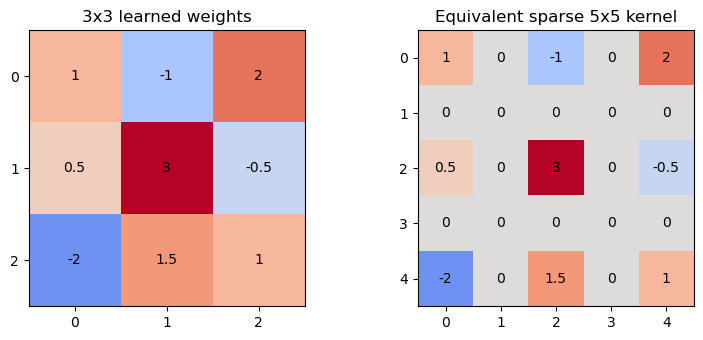

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
vmax = np.abs(kernel_5x5).max()

for ax, kernel, title in zip(
    axes,
    [kernel_3x3, kernel_5x5],
    ["3x3 learned weights", "Equivalent sparse 5x5 kernel"],
):
    ax.imshow(kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    for row in range(kernel.shape[0]):
        for col in range(kernel.shape[1]):
            ax.text(col, row, f"{kernel[row, col]:g}", ha="center", va="center")
    ax.set_title(title)
    ax.set_xticks(range(kernel.shape[1]))
    ax.set_yticks(range(kernel.shape[0]))

plt.tight_layout()
plt.show()

## 2. Apply both operations to the same input

The first function applies the $3\times3$ weights directly at dilated positions. The second performs ordinary valid cross-correlation with the sparse $5\times5$ kernel.

In [ ]:
def dilated_xcorr2d_valid(image, kernel, dilation):
    effective_h = 1 + (kernel.shape[0] - 1) * dilation
    effective_w = 1 + (kernel.shape[1] - 1) * dilation
    windows = sliding_window_view(image, (effective_h, effective_w))
    sampled = windows[..., ::dilation, ::dilation]
    return np.einsum("ijmn,mn->ij", sampled, kernel) # einsum means sum of element-wise multiplication over the last two axes


def xcorr2d_valid(image, kernel):
    windows = sliding_window_view(image, kernel.shape)
    return np.einsum("ijmn,mn->ij", windows, kernel) # einsum means sum of element-wise multiplication over the last two axes


rng = np.random.default_rng(7)
image = rng.normal(size=(9, 9))

output_dilated = dilated_xcorr2d_valid(image, kernel_3x3, dilation=2)
output_sparse = xcorr2d_valid(image, kernel_5x5)

print("Output from dilated 3x3 kernel:\n", output_dilated)
print("\nOutput from sparse 5x5 kernel:\n", output_sparse)

Output from dilated 3x3 kernel:
 [[ -7.18  -4.15  -4.39   3.97  -1.1 ]
 [  2.74  -5.72   3.27  -4.28 -10.03]
 [ -2.7   -1.48   2.89  -3.59 -13.2 ]
 [  0.2   -1.17   6.95   0.36  -9.64]
 [  2.24   4.66  -2.22  -1.89   5.17]]

Output from sparse 5x5 kernel:
 [[ -7.18  -4.15  -4.39   3.97  -1.1 ]
 [  2.74  -5.72   3.27  -4.28 -10.03]
 [ -2.7   -1.48   2.89  -3.59 -13.2 ]
 [  0.2   -1.17   6.95   0.36  -9.64]
 [  2.24   4.66  -2.22  -1.89   5.17]]


## 3. Verify that the outputs are identical

In [5]:
difference = output_dilated - output_sparse

print("Maximum absolute difference:", np.abs(difference).max())
print("Numerically equal:", np.allclose(output_dilated, output_sparse))

assert np.allclose(output_dilated, output_sparse)

Maximum absolute difference: 1.7763568394002505e-15
Numerically equal: True


## Conclusion

The two outputs are the same because both calculations multiply the same nine input positions by the same nine weights. The dilated representation is more economical: it stores and learns **9 parameters**, whereas a general $5\times5$ kernel would contain **25 parameters**. Its equivalence is specifically to a $5\times5$ kernel with the other 16 weights constrained to remain zero.